1-Importing toola to work with data and loads dataset

In [2]:
import pandas as pd

# Manually create dataset from sklearn openml
from sklearn.datasets import fetch_openml

heart = fetch_openml(name='heart-disease', version=1, as_frame=True)
df = heart.frame

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


In [3]:
df.shape

(303, 14)

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [5]:
df['target'].value_counts()

,count
target,
1.0,165
0.0,138


In [6]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
# Features (everything except target)
X = df.drop('target', axis=1)

# Target
y = df['target']

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0


In [8]:
y.head()

,target
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for some models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split and scaled successfully")

Data split and scaled successfully


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

# Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.8525
KNN: 0.9016
Decision Tree: 0.7869
Random Forest: 0.8525
SVM: 0.8689


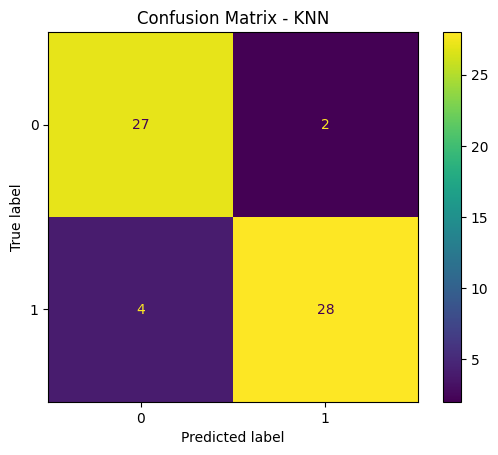

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use best model (KNN)
best_model = KNeighborsClassifier()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - KNN")
plt.show()

In [13]:
from sklearn.metrics import classification_report
import pandas as pd

# Store detailed results
detailed_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    report = classification_report(y_test, preds, output_dict=True)

    detailed_results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": report["1.0"]["precision"],
        "Recall": report["1.0"]["recall"],
        "F1-score": report["1.0"]["f1-score"]
    }

# Convert to DataFrame for clean view
results_df = pd.DataFrame(detailed_results).T

# Show results table
results_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.852459,0.870968,0.84375,0.857143
KNN,0.901639,0.933333,0.87500,0.903226
Decision Tree,0.819672,0.920000,0.71875,0.807018
Random Forest,0.868852,0.852941,0.90625,0.878788
SVM,0.868852,0.900000,0.84375,0.870968


In [14]:
results_df.to_csv("model_results.csv")

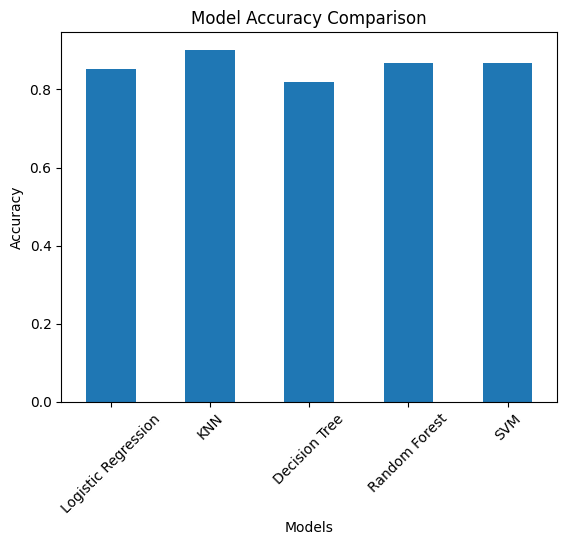

In [15]:
import matplotlib.pyplot as plt

# Plot model accuracy comparison
results_df["Accuracy"].plot(kind='bar')

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()